# 04 — Second-Sensor Zero-Shot Evaluation

**Dataset:** METR-LA  
**Sensor:** `717608`  
**Context:** 96 × 5 min = 8 hours  
**Forecast horizon:** 24 × 5 min = 2 hours  
**Models:** TimesFM 2.5 and Moirai 2.0  
**Training / fine-tuning:** None

This notebook evaluates zero-shot transfer to a second traffic sensor using the same locked time window as the primary-sensor experiment.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving metr-la.h5 to metr-la.h5


In [ ]:
import os
import pandas as pd
import numpy as np

# ============================================================
# SECOND SENSOR ZERO-SHOT — LOCKED CONFIG
# ============================================================

DATA_PATH = "/content/metr-la.h5"

SENSOR_ID = "717608"

CONTEXT_START = "2012-06-04 13:30:00"
CONTEXT_END   = "2012-06-04 21:25:00"

GT_START = "2012-06-04 21:30:00"
GT_END   = "2012-06-04 23:25:00"

CONTEXT_LENGTH = 96
FORECAST_HORIZON = 24

# ============================================================
# 1. LOAD METR-LA
# ============================================================

assert os.path.exists(DATA_PATH), "metr-la.h5 not found."

df = pd.read_hdf(DATA_PATH)

if isinstance(df.index, pd.DatetimeIndex):
    df.index.freq = None

column_lookup = {str(col): col for col in df.columns}

assert SENSOR_ID in column_lookup, \
    f"Sensor {SENSOR_ID} not found."

sensor_column = column_lookup[SENSOR_ID]

series = df[sensor_column].astype(float).sort_index()

# ============================================================
# 2. SAME EXACT WINDOW AS SENSOR 773062
# ============================================================

context = series.loc[CONTEXT_START:CONTEXT_END].copy()
ground_truth = series.loc[GT_START:GT_END].copy()

expected_context_index = pd.date_range(
    CONTEXT_START,
    periods=CONTEXT_LENGTH,
    freq="5min"
)

expected_gt_index = pd.date_range(
    GT_START,
    periods=FORECAST_HORIZON,
    freq="5min"
)

# ============================================================
# 3. STRICT VALIDATION
# ============================================================

assert len(context) == CONTEXT_LENGTH
assert len(ground_truth) == FORECAST_HORIZON

assert context.index.equals(expected_context_index)
assert ground_truth.index.equals(expected_gt_index)

context_nan = int(context.isna().sum())
gt_nan = int(ground_truth.isna().sum())

context_zero = int((context == 0).sum())
gt_zero = int((ground_truth == 0).sum())

print("==========================================")
print("SECOND SENSOR WINDOW VALIDATION")
print("==========================================")
print("Sensor:", SENSOR_ID)
print("Variable: traffic speed")
print("Sampling interval: 5 minutes")
print()
print("Context:", len(context))
print("Forecast horizon:", len(ground_truth))
print()
print("Context window:")
print(context.index[0], "→", context.index[-1])
print()
print("Ground truth window:")
print(ground_truth.index[0], "→", ground_truth.index[-1])
print()
print("NaN in context:", context_nan)
print("NaN in ground truth:", gt_nan)
print("Zeros in context:", context_zero)
print("Zeros in ground truth:", gt_zero)
print()
print("First 5 context values:")
print(context.head().to_numpy())
print()
print("First 5 ground-truth values:")
print(ground_truth.head().to_numpy())

# ============================================================
# 4. ONLY SAVE IF WINDOW IS CLEAN
# ============================================================

if (
    context_nan == 0
    and gt_nan == 0
    and context_zero == 0
    and gt_zero == 0
):
    evaluation_window = pd.DataFrame({
        "timestamp": list(context.index) + list(ground_truth.index),
        "traffic_speed": list(context.values) + list(ground_truth.values),
        "split": ["context"] * 96 + ["ground_truth"] * 24
    })

    SAVE_PATH = "/content/evaluation_window_sensor_717608.csv"
    evaluation_window.to_csv(SAVE_PATH, index=False)

    print()
    print("✅ SAME EXACT WINDOW IS CLEAN")
    print("Saved:", SAVE_PATH)
    print("Rows:", len(evaluation_window))

else:
    print()
    print("⚠️ SAME WINDOW IS NOT CLEAN")
    print("Do NOT run any model yet.")

SECOND SENSOR WINDOW VALIDATION
Sensor: 717608
Variable: traffic speed
Sampling interval: 5 minutes

Context: 96
Forecast horizon: 24

Context window:
2012-06-04 13:30:00 → 2012-06-04 21:25:00

Ground truth window:
2012-06-04 21:30:00 → 2012-06-04 23:25:00

NaN in context: 0
NaN in ground truth: 0
Zeros in context: 0
Zeros in ground truth: 0

First 5 context values:
[66.25       66.375      66.88888889 66.5        67.42857143]

First 5 ground-truth values:
[67.625      68.25       68.44444444 68.625      68.66666667]

✅ SAME EXACT WINDOW IS CLEAN
Saved: /content/evaluation_window_sensor_717608.csv
Rows: 120


In [ ]:
from google.colab import files

files.download("/content/evaluation_window_sensor_717608.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Validated model-output provenance

The final comparison below uses only validated finite predictions:

- **TimesFM 2.5:** valid T4 inference from checkpoint `google/timesfm-2.5-200m-pytorch`.
- **Moirai 2.0:** valid zero-shot inference from checkpoint `Salesforce/moirai-2.0-R-small` using Uni2TS 2.0.0.
- Both predictions use the **q=0.5 median**, the same 96-step context, and the same 24-step target window.

A historical shared-CPU TimesFM attempt produced NaN outputs and is intentionally excluded from the scientific comparison. Inference-speed comparisons are also excluded because the validated model runs used different environments/devices.


In [ ]:
import os
import numpy as np
import pandas as pd

# ============================================================
# SENSOR B — FINAL VERIFIED COMPARISON
# ============================================================

EVAL_PATH = "/content/evaluation_window_sensor_717608.csv"
TIMESFM_PATH = "/content/timesfm_predictions_sensor_717608.csv"

# This file contains the previously VALID Moirai 2.0 predictions.
# Its old TimesFM column is intentionally ignored.
OLD_COMPARISON_PATH = "/content/second_sensor_model_comparison.csv"

FINAL_PRED_PATH = "/content/second_sensor_final_comparison.csv"
FINAL_METRICS_PATH = "/content/second_sensor_final_metrics.csv"

# ============================================================
# 1. FILE CHECK
# ============================================================

required = [
    EVAL_PATH,
    TIMESFM_PATH,
    OLD_COMPARISON_PATH,
]

for path in required:
    assert os.path.exists(path), f"Missing file: {path}"

print("Required files: OK")

# ============================================================
# 2. LOAD
# ============================================================

ev = pd.read_csv(EVAL_PATH, parse_dates=["timestamp"])
tfm = pd.read_csv(TIMESFM_PATH, parse_dates=["timestamp"])
old = pd.read_csv(OLD_COMPARISON_PATH, parse_dates=["timestamp"])

gt = (
    ev[ev["split"] == "ground_truth"]
    [["timestamp", "traffic_speed"]]
    .rename(columns={"traffic_speed": "ground_truth"})
    .reset_index(drop=True)
)

assert len(gt) == 24
assert len(tfm) == 24
assert len(old) == 24

# ============================================================
# 3. STRICT TIMESTAMP + GROUND-TRUTH AUDIT
# ============================================================

assert np.array_equal(
    gt["timestamp"].to_numpy(),
    tfm["timestamp"].to_numpy()
), "TimesFM timestamps mismatch."

assert np.array_equal(
    gt["timestamp"].to_numpy(),
    old["timestamp"].to_numpy()
), "Moirai timestamps mismatch."

assert np.allclose(
    gt["ground_truth"].to_numpy(dtype=float),
    tfm["ground_truth"].to_numpy(dtype=float)
), "TimesFM ground truth mismatch."

assert np.allclose(
    gt["ground_truth"].to_numpy(dtype=float),
    old["ground_truth"].to_numpy(dtype=float)
), "Moirai ground truth mismatch."

# ============================================================
# 4. EXTRACT ONLY VALID MODEL OUTPUTS
# ============================================================

timesfm_pred = tfm["timesfm_prediction"].to_numpy(dtype=float)
moirai_pred = old["moirai_2_0"].to_numpy(dtype=float)
y_true = gt["ground_truth"].to_numpy(dtype=float)

assert timesfm_pred.shape == (24,)
assert moirai_pred.shape == (24,)

assert np.isfinite(timesfm_pred).all(), \
    "FAIL: Valid T4 TimesFM result contains NaN/Inf."

assert np.isfinite(moirai_pred).all(), \
    "FAIL: Moirai result contains NaN/Inf."

# ============================================================
# 5. RECOMPUTE METRICS FROM PREDICTIONS
# ============================================================

timesfm_mae = np.mean(np.abs(y_true - timesfm_pred))
timesfm_rmse = np.sqrt(np.mean((y_true - timesfm_pred) ** 2))

moirai_mae = np.mean(np.abs(y_true - moirai_pred))
moirai_rmse = np.sqrt(np.mean((y_true - moirai_pred) ** 2))

assert np.isfinite([
    timesfm_mae,
    timesfm_rmse,
    moirai_mae,
    moirai_rmse
]).all()

# Cross-check against the values we already observed
assert round(timesfm_mae, 4) == 1.3665
assert round(timesfm_rmse, 4) == 2.5878
assert round(moirai_mae, 4) == 1.3389
assert round(moirai_rmse, 4) == 2.5547

# ============================================================
# 6. BUILD CLEAN FINAL ARTIFACTS
# ============================================================

comparison = pd.DataFrame({
    "timestamp": gt["timestamp"],
    "ground_truth": y_true,
    "timesfm_2_5": timesfm_pred,
    "moirai_2_0": moirai_pred,
})

metrics = pd.DataFrame([
    {
        "sensor": "717608",
        "model": "TimesFM",
        "version": "2.5",
        "checkpoint": "google/timesfm-2.5-200m-pytorch",
        "forecast_type": "q=0.5 median",
        "context_length": 96,
        "forecast_horizon": 24,
        "zero_shot": True,
        "mae": timesfm_mae,
        "rmse": timesfm_rmse,
    },
    {
        "sensor": "717608",
        "model": "Moirai",
        "version": "2.0",
        "checkpoint": "Salesforce/moirai-2.0-R-small",
        "forecast_type": "q=0.5 median",
        "context_length": 96,
        "forecast_horizon": 24,
        "zero_shot": True,
        "mae": moirai_mae,
        "rmse": moirai_rmse,
    }
])

comparison.to_csv(FINAL_PRED_PATH, index=False)
metrics.to_csv(FINAL_METRICS_PATH, index=False)

# ============================================================
# 7. FINAL REPORT
# ============================================================

print()
print("============================================")
print("SENSOR 717608 — FINAL INTEGRITY REPORT")
print("============================================")
print("Timestamps identical: YES")
print("Ground truth identical: YES")
print("TimesFM finite predictions: YES")
print("Moirai finite predictions: YES")
print("Context: 96")
print("Horizon: 24")
print("Forecast type: q=0.5 median")
print("Training / fine-tuning: NONE")
print()

print(
    metrics[
        ["model", "version", "mae", "rmse"]
    ].to_string(index=False)
)

print()
print("Saved:")
print(FINAL_PRED_PATH)
print(FINAL_METRICS_PATH)

print()
print("✅ SENSOR 717608 FINAL COMPARISON VERIFIED")

Required files: OK

SENSOR 717608 — FINAL INTEGRITY REPORT
Timestamps identical: YES
Ground truth identical: YES
TimesFM finite predictions: YES
Moirai finite predictions: YES
Context: 96
Horizon: 24
Forecast type: q=0.5 median
Training / fine-tuning: NONE

  model version      mae     rmse
TimesFM     2.5 1.366497 2.587771
 Moirai     2.0 1.338948 2.554746

Saved:
/content/second_sensor_final_comparison.csv
/content/second_sensor_final_metrics.csv

✅ SENSOR 717608 FINAL COMPARISON VERIFIED


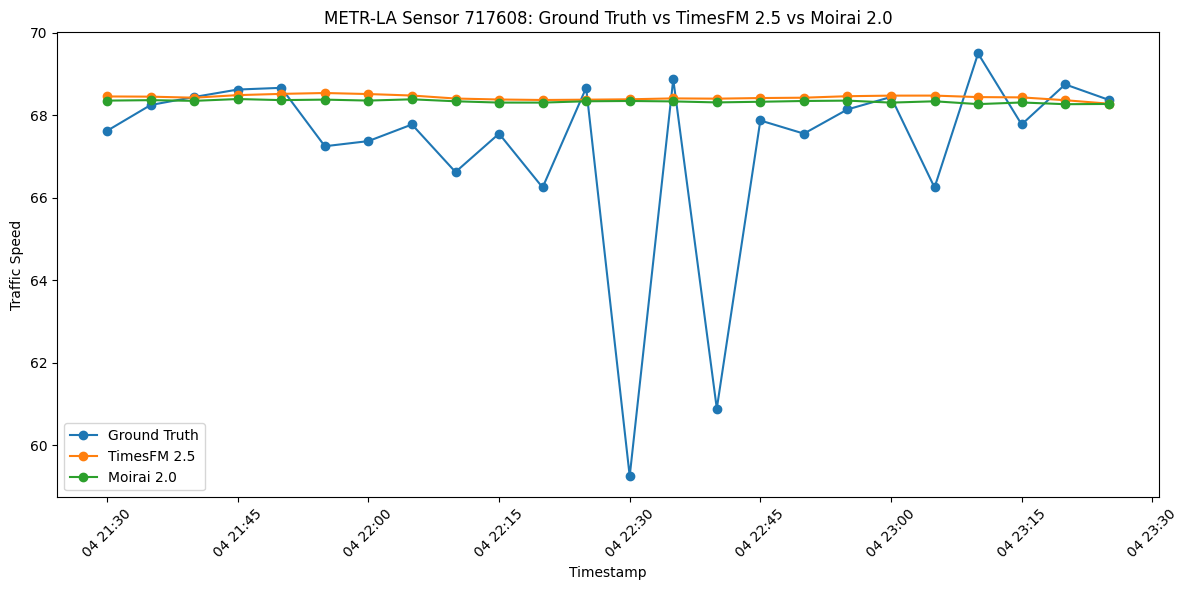

Saved: /content/second_sensor_comparison_plot.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/content/second_sensor_final_comparison.csv",
    parse_dates=["timestamp"]
)

plt.figure(figsize=(12, 6))

plt.plot(
    df["timestamp"],
    df["ground_truth"],
    marker="o",
    label="Ground Truth"
)

plt.plot(
    df["timestamp"],
    df["timesfm_2_5"],
    marker="o",
    label="TimesFM 2.5"
)

plt.plot(
    df["timestamp"],
    df["moirai_2_0"],
    marker="o",
    label="Moirai 2.0"
)

plt.title(
    "METR-LA Sensor 717608: "
    "Ground Truth vs TimesFM 2.5 vs Moirai 2.0"
)

plt.xlabel("Timestamp")
plt.ylabel("Traffic Speed")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

OUTPUT = "/content/second_sensor_comparison_plot.png"

plt.savefig(
    OUTPUT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", OUTPUT)

In [ ]:
from google.colab import files

files.download("/content/second_sensor_comparison_plot.png")
files.download("/content/second_sensor_final_comparison.csv")
files.download("/content/second_sensor_final_metrics.csv")
files.download("/content/evaluation_window_sensor_717608.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>